
              precision    recall  f1-score   support

     healing       0.85      0.85      0.85        13
 non-healing       0.82      0.82      0.82        11

    accuracy                           0.83        24
   macro avg       0.83      0.83      0.83        24
weighted avg       0.83      0.83      0.83        24

Accuracy: 83.33333333333334 %


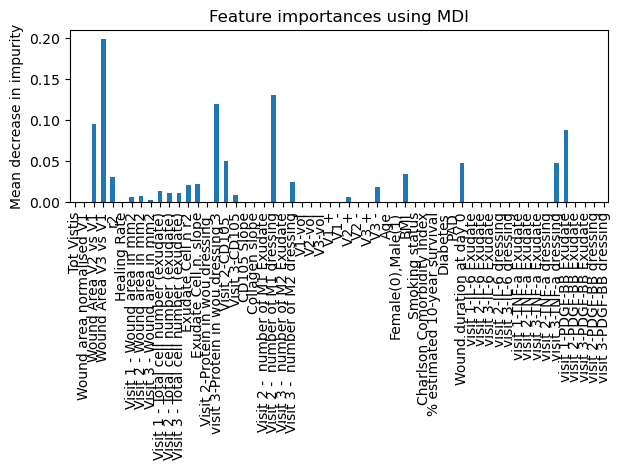

[[0.22554952 0.7744505 ]
 [0.06857109 0.9314289 ]
 [0.96098924 0.03901076]
 [0.9936974  0.0063026 ]
 [0.7204877  0.27951232]
 [0.98436105 0.01563892]
 [0.09554952 0.9044505 ]
 [0.10879534 0.89120466]
 [0.8654152  0.1345848 ]
 [0.584816   0.41518402]
 [0.04939014 0.95060986]
 [0.29024333 0.7097567 ]
 [0.97383857 0.02616144]
 [0.05027968 0.9497203 ]
 [0.6261748  0.3738252 ]
 [0.86775744 0.13224258]
 [0.76464725 0.23535278]
 [0.1252982  0.8747018 ]
 [0.11314827 0.8868517 ]
 [0.9786926  0.02130739]
 [0.01901311 0.9809869 ]
 [0.99148655 0.00851344]
 [0.65768176 0.34231824]
 [0.3398068  0.6601932 ]]
[ True  True False False False False  True  True False False  True  True
 False  True False False False  True  True False  True False False  True]


<Figure size 40000x12000 with 0 Axes>

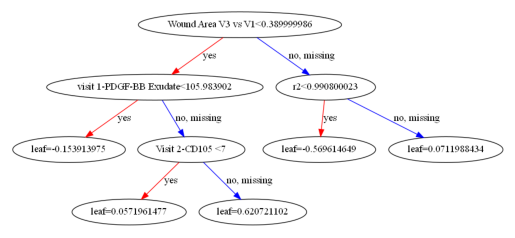

--------------------------------------------------------------------------------------------------


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from xgboost import *
from dtreeviz import model

name="Correct full.txt"
W_tree=1
class_names=["healing","non-healing"]

Treatment=pd.read_csv("../AD report/Correct full train.csv")
Treatment_test=pd.read_csv("../AD report/Correct full test.csv")

X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]

clf=XGBClassifier(tree_method="hist",
                  colsample_bynode=0.7,
                  max_depth=None,
                  eta=0.5,
                  #subsample =0.7,
                  objective="reg:logistic"
                  
                  
    )




clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()



f = open(name, "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))
print(y_pred)


plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()








print("--------------------------------------------------------------------------------------------------")

target = 'key'



#Which_data=df_y_test
Which_data=y_train

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_train, 
    Which_data, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)